# Линейная регрессия

Линейная регрессия - модель зависимости переменной от одной или нескольких других переменных с линейной функцией зависимости.

## Открываем файл для анализа

In [1]:
import pandas as pd  # импорт библиотеки pandas для манипуляции данными
houses_df = pd.read_csv('https://raw.githubusercontent.com/ywchiu/riii/master/data/house-prices.csv') # открываем файл для анализа
houses_df.head()  # оцениваем содержимое таблицы


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [2]:
houses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Home          128 non-null    int64 
 1   Price         128 non-null    int64 
 2   SqFt          128 non-null    int64 
 3   Bedrooms      128 non-null    int64 
 4   Bathrooms     128 non-null    int64 
 5   Offers        128 non-null    int64 
 6   Brick         128 non-null    object
 7   Neighborhood  128 non-null    object
dtypes: int64(6), object(2)
memory usage: 8.1+ KB


## График зависимости цены от площади

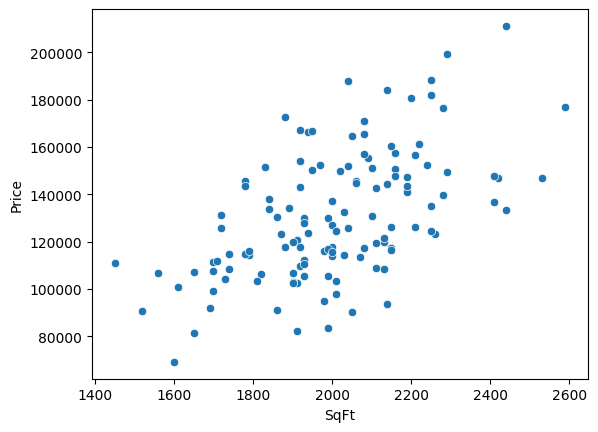

In [ ]:
import seaborn as sns # импортируем библиотеку построения графиков
ax = sns.scatterplot(x="SqFt", y="Price", data=houses_df) # строим график

Задача линейной регрессии - найти прямую линию, максимально приближенную ко всем точкам на графике, чтобы используя эту линейную функцию мы могли предсказать значение искомой зависимой переменной для произвольной независимой переменной

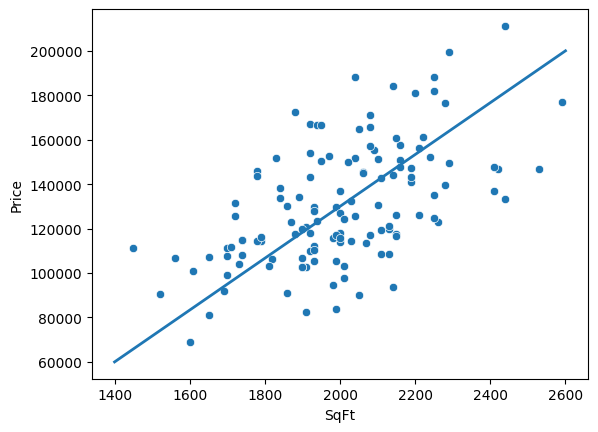

In [ ]:
import matplotlib.pyplot as plt # импортируем библиотеку содержащую функцию построения прямой линии
ax = sns.scatterplot(x="SqFt", y="Price", data=houses_df) # строим график
plt.plot([1400, 2600], [60000, 200000], linewidth=2) # добавляем на график прямую линию


Восстановление регрессии - это вид задачи обучения с учителем

In [3]:
houses_df = pd.read_csv('https://raw.githubusercontent.com/ywchiu/riii/master/data/house-prices.csv', usecols=['Price','SqFt']) # открываем файл для анализа
houses_df.head()  # оцениваем содержимое таблицы

,Price,SqFt
0,114300,1790
1,114200,2030
2,114800,1740
3,94700,1980
4,119800,2130


В машинном обучении мы работаем мы тренируем алгоритм на **наборах данных (data set)**. Загруженная нами таблица называется **обучающая выборка (traning set)**.

Независимая переменная - SqFt (площадь в $футах^2$) - **признак (feature)** - x

Зависимая переменная - Price (цена дома) - **целевая перемеменная (target variable)** - y

Один набор из (x,y) - **обучающий набор (training example)**

($x^{(i)}, y^{(i)}$) - i-й обучающий набор, где i - изменяющийся номер строки в наборе данных

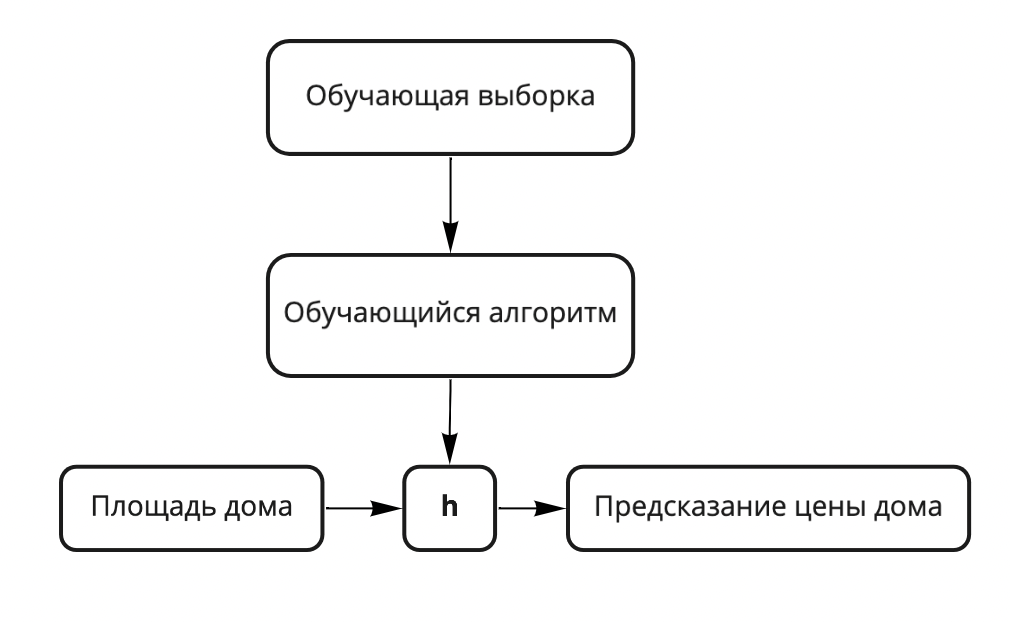



**h (гипотеза)** - функция, которая преобразует переданные x в у

для линейной регрессии эта функция имеет вид:

$h = ϴ_0 + ϴ_1x$

уравнение прямой линии:

$y = ax + b$

Работа обучающегося алгоритма - подобрать **параметры модели** - $ϴ_0$ и $ϴ_1$

## Смысл параметров

$ϴ_0$ = 1

$ϴ_1$ = 0

$h = 1 + 0·x$

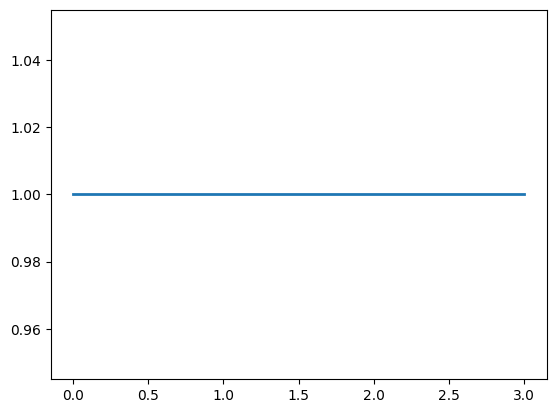

In [ ]:
plt.plot([0, 3], [1, 1], linewidth=2)

$ϴ_0$ = 0

$ϴ_1$ = 1

$h = 0 + 1·x$

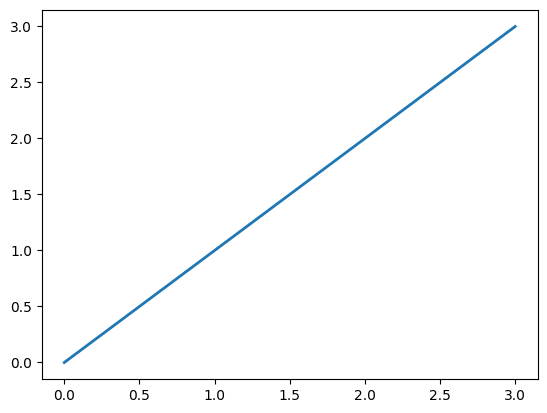

In [ ]:
plt.plot([0, 3], [0, 3], linewidth=2)

$ϴ_0$ = 1

$ϴ_1$ = 0.5

$h = 1 + 0.5·x$

(0.0, 3.0)

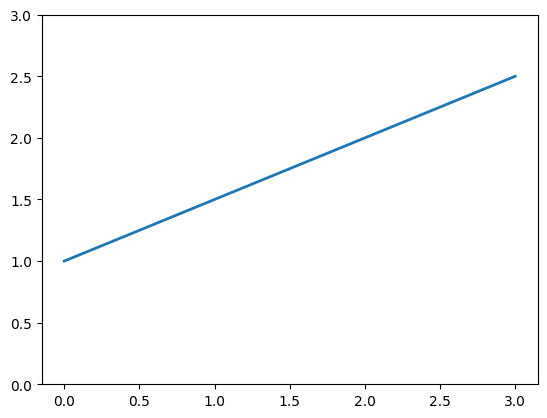

In [ ]:
plt.plot([0, 3], [1, 2.5], linewidth=2)
axes = plt.gca()
axes.set_ylim([0,3])

## Функция потерь (cost function, lost function)

мера того, насколько точно ваша модель способна предсказать ожидаемый результат

$J(ϴ_0, ϴ_1) = \frac{1}{2m}\sum\limits_{i=1}^m(h(x^{(i)})-y^{(i)})^2$

Задача обучающегося алгоритма - подобрать $ϴ_0$ и $ϴ_1$ так, чтобы $J(ϴ_0, ϴ_1)$ имела минимальное значение

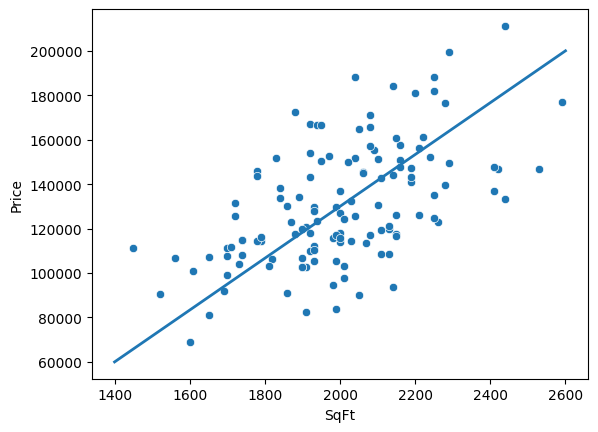

In [ ]:
ax = sns.scatterplot(x="SqFt", y="Price", data=houses_df) # строим график
plt.plot([1400, 2600], [60000, 200000], linewidth=2) # добавляем на график прямую линию

## График упрощенной функции потерь

$ϴ_0$ = 0

$h = ϴ_1·x$

$\underset{ϴ_1}{minimize} J(ϴ_1)$



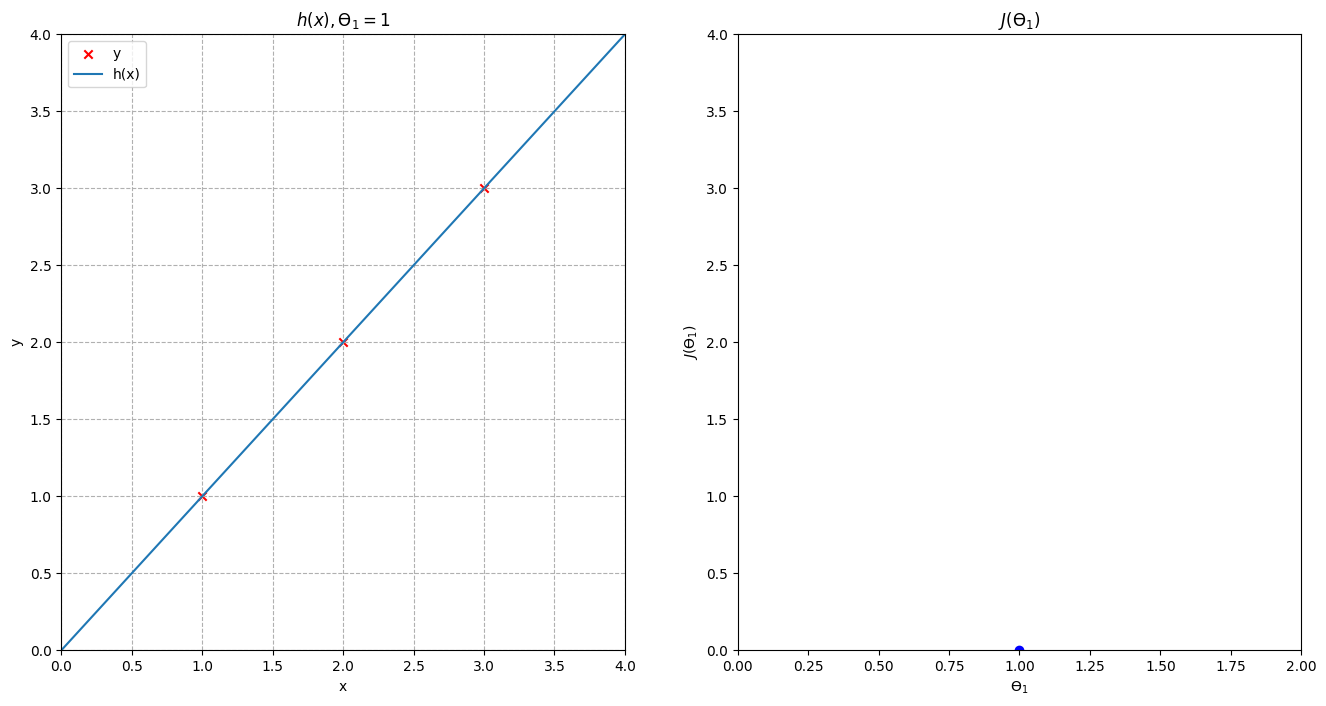

In [ ]:
fig = plt.figure()
fig.set_size_inches(16, 8)
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_xlim([0, 4])
ax1.set_ylim([0, 4])
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(r'$h(x), ϴ_1 = 1$')
ax1.scatter([1,2,3], [1,2,3], color = 'red', marker = 'x', label = 'y')
ax1.plot([0,5], [0,5], label = 'h(x)')
ax1.legend()
ax1.grid(linestyle = '--')
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_xlim([0, 2])
ax2.set_ylim([0, 4])
ax2.set_xlabel(r'$ϴ_1$')
ax2.set_ylabel(r'$J(ϴ_1)$')
ax2.set_title(r'$J(ϴ_1)$')
ax2.scatter([1], [0], color = 'blue')
plt.show()


$J(ϴ_1) = \frac{1}{2m}\sum\limits_{i=1}^m(h(x^{(i)})-y^{(i)})^2 = \frac{1}{2·3} ((1-1)^2 + (2-2)^2 + (3-3)^2) = \frac{1}{6} (0^2 + 0^2 + 0^2) = 0$

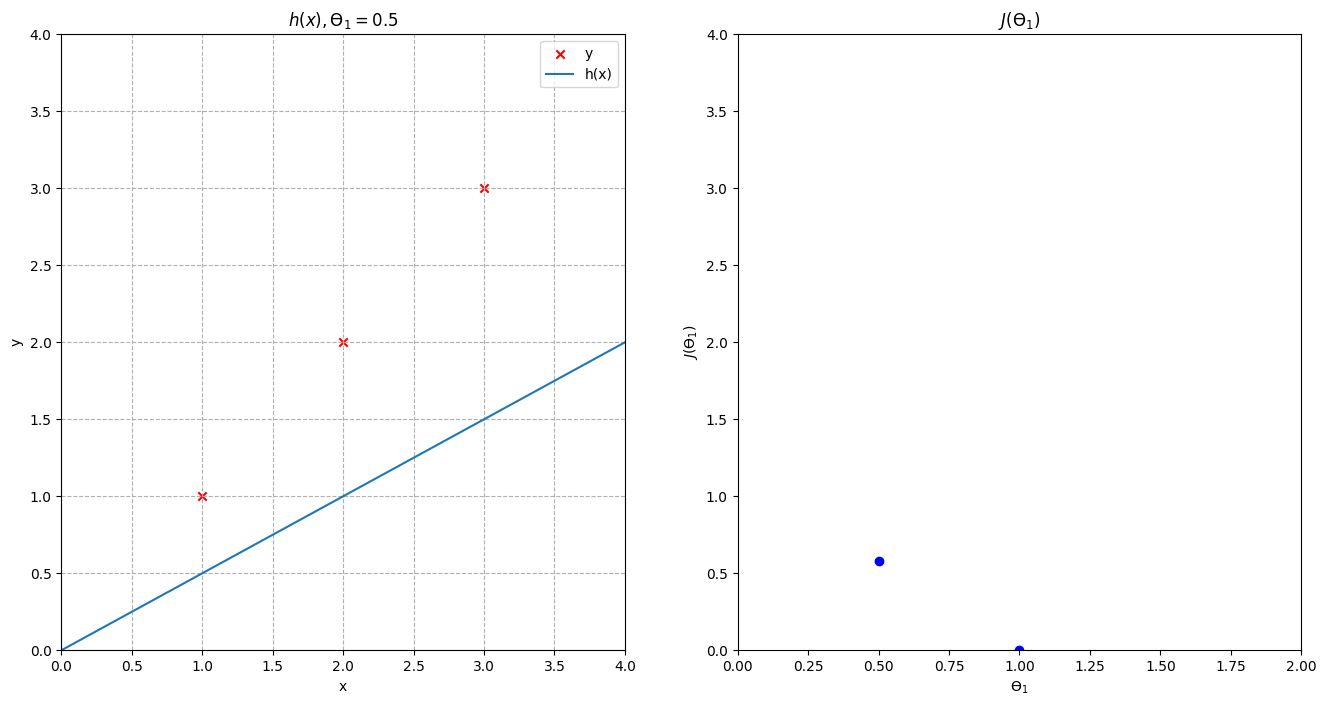

In [ ]:
fig = plt.figure()
fig.set_size_inches(16, 8)
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_xlim([0, 4])
ax1.set_ylim([0, 4])
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(r'$h(x), ϴ_1 = 0.5$')
ax1.scatter([1,2,3], [1,2,3], color = 'red', marker = 'x', label = 'y')
ax1.plot([0,5], [0,2.5], label = 'h(x)')
ax1.legend()
ax1.grid(linestyle = '--')
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_xlim([0, 2])
ax2.set_ylim([0, 4])
ax2.set_xlabel(r'$ϴ_1$')
ax2.set_ylabel(r'$J(ϴ_1)$')
ax2.set_title(r'$J(ϴ_1)$')
ax2.scatter([1, 0.5], [0, 0.58], color = 'blue')
plt.show()

$J(ϴ_1) = \frac{1}{2m}\sum\limits_{i=1}^m(h(x^{(i)})-y^{(i)})^2 = \frac{1}{2·3} ((0.5-1)^2 + (1-2)^2 + (1.5-3)^2) = \frac{1}{6}(0.25 + 1 + 2.25) = 0.58$

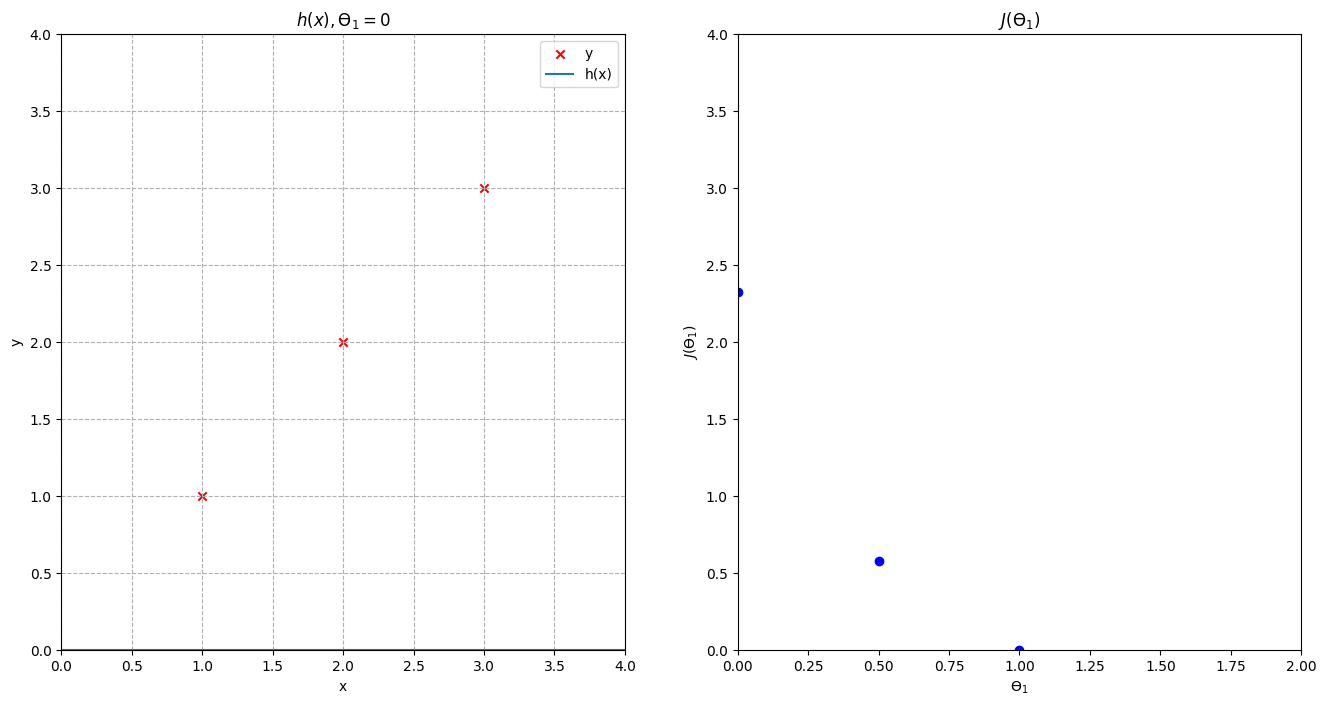

In [ ]:
fig = plt.figure()
fig.set_size_inches(16, 8)
ax1 = fig.add_subplot(1, 2, 1)
ax1.set_xlim([0, 4])
ax1.set_ylim([0, 4])
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(r'$h(x), ϴ_1 = 0$')
ax1.scatter([1,2,3], [1,2,3], color = 'red', marker = 'x', label = 'y')
ax1.plot([0,5], [0,0], label = 'h(x)')
ax1.legend()
ax1.grid(linestyle = '--')
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_xlim([0, 2])
ax2.set_ylim([0, 4])
ax2.set_xlabel(r'$ϴ_1$')
ax2.set_ylabel(r'$J(ϴ_1)$')
ax2.set_title(r'$J(ϴ_1)$')
ax2.scatter([1, 0.5, 0], [0, 0.58, 2.33], color = 'blue')
plt.show()

$J(ϴ_1) = \frac{1}{2m}\sum\limits_{i=1}^m(h(x^{(i)})-y^{(i)})^2 = \frac{1}{2·3} ((0-1)^2 + (0-2)^2 + (0-3)^2) = \frac{1}{6}(1 + 4 + 9) \approx 2.333$

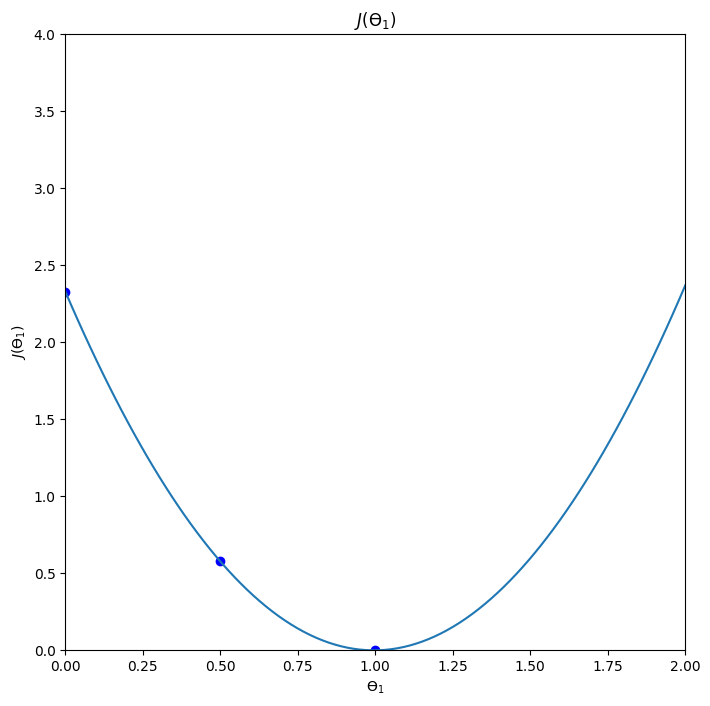

In [ ]:
import numpy as np

x = np.linspace(0, 2, 100)
y = 2.35*x**2 - 4.68 * x + 2.33

fig = plt.figure()
fig.set_size_inches(8, 8)
ax = fig.add_subplot(1, 1, 1)
ax.set_xlim([0, 2])
ax.set_ylim([0, 4])
ax.set_xlabel(r'$ϴ_1$')
ax.set_ylabel(r'$J(ϴ_1)$')
ax.set_title(r'$J(ϴ_1)$')
ax.scatter([1, 0.5, 0], [0, 0.58, 2.33], color = 'blue')
ax.plot(x, y)
plt.show()

$J(ϴ_0,ϴ_1)$

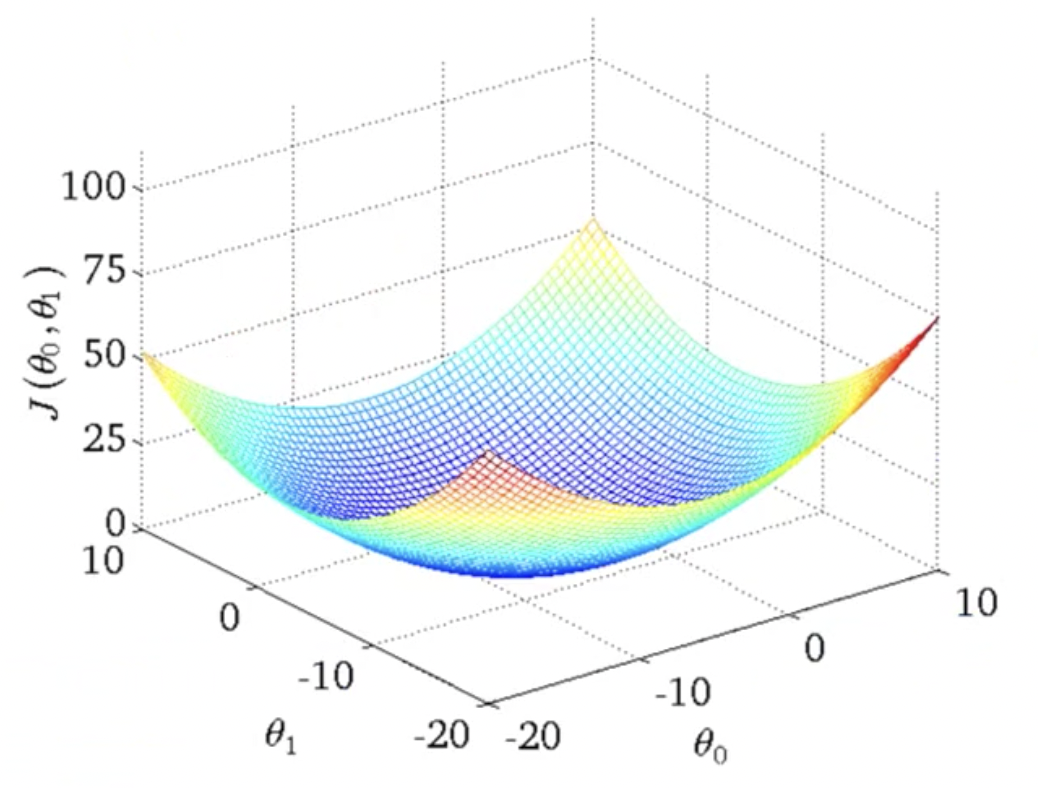

# Алгоритм градиентного спуска (gradient descent)

Задача: минимизировать $J(ϴ_0,ϴ_1)$

Идея алгоритма:

1.   Начать с произвольных значений $ϴ_0$ и $ϴ_1$
2.   Изменять значения $ϴ_0$ и $ϴ_1$ так, чтобы уменьшалось значение $J(ϴ_0,ϴ_1)$ пока не дойдем до мимимального значения


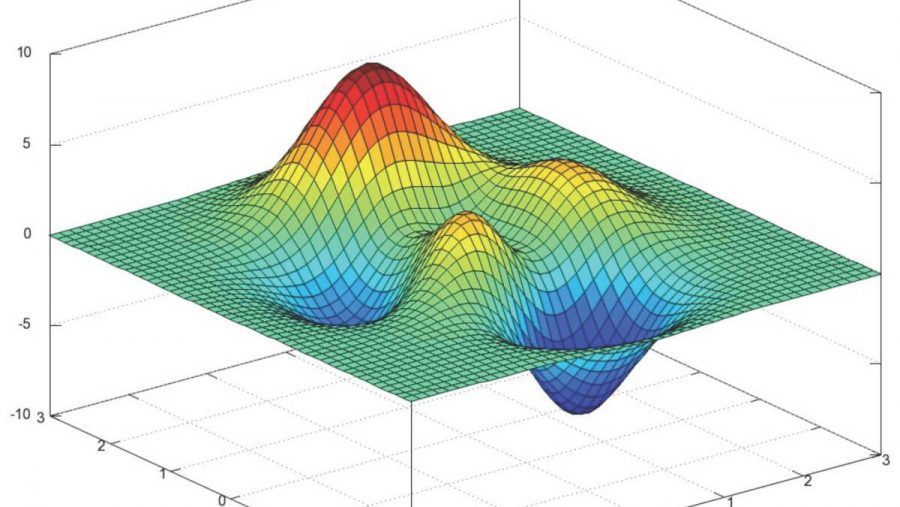

## Производная

$f'(x) = \lim\limits_{x \to x_0} \frac{f(x) - f(x_0)}{x - x_0} $

Производная функции − это результат дифференцирования функции.

Дифференцирование в математике — это процесс, при котором функция f превращается в другую функцию f’ ("производная от f").

Простыми словами, производная — это средний наклон функции между двумя точками

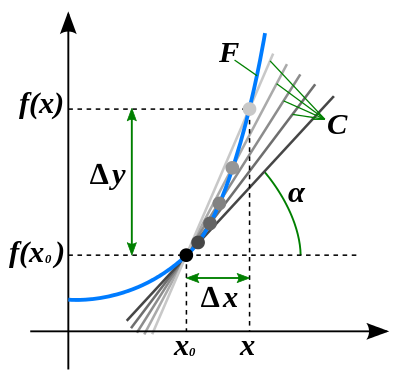

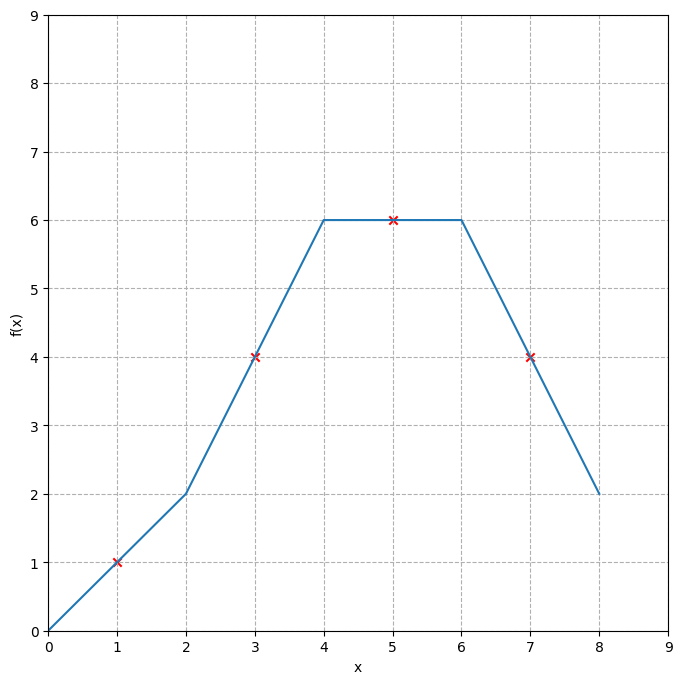

In [ ]:
fig = plt.figure()
fig.set_size_inches(8, 8)
ax1 = fig.add_subplot(1, 1, 1)
ax1.set_xlim([0, 9])
ax1.set_ylim([0, 9])
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.scatter([1,3,5,7], [1,4,6,4], color = 'red', marker = 'x')
ax1.plot([0,2,4,6,8], [0,2,6,6,2])
ax1.grid(linestyle = '--')
plt.show()

$f'(x) = \frac{f(x) - f(x_0)}{x - x_0} $

$f'(1) = \frac{1 - 0}{1 - 0} = \frac{1}{1} = 1$

$f'(3) = \frac{4 - 2}{3 - 2} = \frac{2}{1} = 2$

$f'(5) = \frac{6 - 6}{5 - 4} = \frac{0}{1} = 0$

$f'(5) = \frac{4 - 6}{7 - 6} = \frac{-2}{1} = -2$

Производная характеризует угол наклона функции в точке

## Алгоритм



повторить на каждом шаге {

$ϴ_{i+1} := ϴ_i - α \frac{\partial }{\partial ϴ_i}J(ϴ_0,ϴ_1)$

}

где α - коэффициент скорости обучения (learning rate)

новое значение $ϴ_{i+1}$ = текущее значение $ϴ_i$ - (коэффициент скорости обучения) * (производная функции потерь)

коэффициент скорости обучения - множитель, который описывает насколько большими шагами мы будем идти к цели

В производной для нас важны 2 параметра:

1.   Знак
2.   Угол наклона

Когда знак производной отрицательный выражение приобретает вид:

$ϴ_{i+1} := ϴ_i - α · $(отрицательное число)

и с каждым шагом $ϴ_{i+1}$ увеличивается (сдвигается на графике вправо)

Когда знак производной положительный выражение приобретает вид:

$ϴ_{i+1} := ϴ_i - α · $(положительное число)

и с каждым шагом $ϴ_{i+1}$ уменьшается (сдвигается на графике влево)

От угла наклона касательной зависит численное значение производной. Чем больше угол - тем больше численное значение производной и тем большими шагами мы идем к цели. Как только производная становится равной 0 - алгоритм перестает изменять $ϴ_{i+1}$


0: f(-8.00000) = 64.00000, derivative = -16.00000
1: f(11.20000) = 125.44000, derivative = 22.40000
2: f(-15.68000) = 245.86240, derivative = -31.36000
3: f(21.95200) = 481.89030, derivative = 43.90400
4: f(-30.73280) = 944.50500, derivative = -61.46560
5: f(43.02592) = 1851.22979, derivative = 86.05184
6: f(-60.23629) = 3628.41039, derivative = -120.47258
7: f(84.33080) = 7111.68437, derivative = 168.66161
8: f(-118.06312) = 13938.90136, derivative = -236.12625
9: f(165.28837) = 27320.24667, derivative = 330.57675
10: f(-231.40372) = 53547.68347, derivative = -462.80745
11: f(323.96521) = 104953.45961, derivative = 647.93043
12: f(-453.55130) = 205708.78083, derivative = -907.10260
13: f(634.97182) = 403189.21042, derivative = 1269.94364
14: f(-888.96055) = 790250.85242, derivative = -1777.92109
15: f(1244.54476) = 1548891.67075, derivative = 2489.08953
16: f(-1742.36267) = 3035827.67467, derivative = -3484.72534
17: f(2439.30774) = 5950222.24236, derivative = 4878.61548
18: f(-3415.0

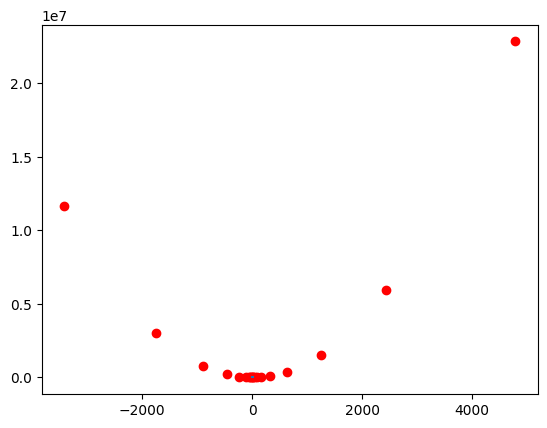

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def parabola(x):
	return x**2

def derivative(x):
  return x*2

x = np.linspace(-10, 10, 100)
y = parabola(x)

solutions = []
evaluations = []

# learning_rate = 0.1
# learning_rate = 0.9
learning_rate = 1.2

# Q = 9
Q = -8

for i in range(20):
  solutions.append(Q)
  evaluations.append(parabola(Q))

  print('%d: f(%.5f) = %.5f, derivative = %.5f' % (i, Q, parabola(Q), derivative(Q)))
  Q = Q - learning_rate * derivative(Q)


plt.plot(x, y)
plt.scatter(solutions, evaluations, color='red')

# scikit-learn

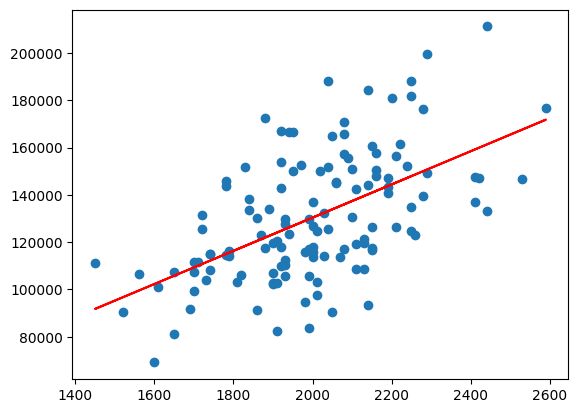

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Преобразуем столбцы из датасета в формат для библиотеки sklearn
SqFt = houses_df['SqFt'].to_numpy().reshape(len(houses_df['SqFt']), 1)
Price = houses_df['Price'].to_numpy().reshape(len(houses_df['Price']), 1)

regression_model = LinearRegression() # создаем модель - линейная регрессия
regression_model.fit(SqFt, Price)     # обучаем модель
h = regression_model.predict(SqFt)    # предсказываем значения

plt.scatter(SqFt, Price)
plt.plot(SqFt, h, color='r')


In [ ]:
print("houses_df['SqFt']")
print(houses_df['SqFt'][:10], '\n')
print("houses_df['SqFt'].to_numpy()")
print(houses_df['SqFt'].to_numpy()[:10], '\n')
print("houses_df['SqFt'].to_numpy().reshape(len(houses_df['SqFt']), 1)")
print(houses_df['SqFt'].to_numpy().reshape(len(houses_df['SqFt']), 1)[:10])

houses_df['SqFt']
0    1790
1    2030
2    1740
3    1980
4    2130
5    1780
6    1830
7    2160
8    2110
9    1730
Name: SqFt, dtype: int64 

houses_df['SqFt'].to_numpy()
[1790 2030 1740 1980 2130 1780 1830 2160 2110 1730] 

houses_df['SqFt'].to_numpy().reshape(len(houses_df['SqFt']), 1)
[[1790]
 [2030]
 [1740]
 [1980]
 [2130]
 [1780]
 [1830]
 [2160]
 [2110]
 [1730]]


In [ ]:
house_square = 2400
prediction = regression_model.predict([[house_square]])
print("Площадь: %.2f  \nЦена: %.2f$" % (house_square, prediction))

Площадь: 2400.00  
Цена: 158452.03$


/tmp/ipykernel_372/878909277.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Площадь: %.2f  \nЦена: %.2f$" % (house_square, prediction))
